# 03 — Segmentation: where the loss actually sits

Notebook 02 asked *when* loss emerges. This one asks *where* — which slices of
the book carry it.

The mechanics are the same ones an actuary uses to build a rating plan: split
the exposure into homogeneous segments, measure loss for each, and check whether
the price charged tracks the loss incurred. In consumer credit this is called
**risk-based pricing**; in insurance it is called a rate table. Same object.

One extra move that consumer credit forces on you: **decompose loss into
frequency and severity.** A segment can be expensive because a lot of its loans
fail, or because the ones that fail lose more. Those are different problems with
different fixes, and the aggregate loss rate hides which one you have.

$$\text{net loss rate} \;\approx\; \underbrace{P(\text{charge-off})}_{\text{frequency}} \times \underbrace{\text{LGD}}_{\text{severity}}$$

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src import data_prep as dp  # noqa: E402
from src import plotting as pl  # noqa: E402

pl.set_style()

df = pd.read_parquet(dp.PROCESSED)

# LendingClub's own policy floor was a 660 FICO, so the "<660" bucket contains a
# literal handful of exceptions. Drop it rather than plot a segment built on two
# loans; a rate computed on a couple of observations carries no real information.
df = df[df["fico_band"] != "<660"].copy()
df["fico_band"] = df["fico_band"].cat.remove_unused_categories()

print(f"Modeling table: {len(df):,} fully-seasoned, resolved loans")
print(f"Exposure:       ${df['funded_amnt'].sum()/1e9:.2f}B funded principal")


def segment_stats(frame: pd.DataFrame, by: str) -> pd.DataFrame:
    """
    Loss decomposition for one segmentation.

    Everything dollar-weighted except the frequency column, which is a loan
    count -- because "how often does a loan fail" is a per-loan question while
    "how much does the book lose" is a per-dollar one.
    """
    g = frame.groupby(by, observed=True)
    out = pd.DataFrame(
        {
            "Loans": g.size(),
            "Funded ($M)": g["funded_amnt"].sum() / 1e6,
            "Avg loan ($)": g["funded_amnt"].mean(),
            "Avg rate": g["int_rate"].mean() / 100,
            "Frequency": g["charged_off"].mean(),
            "Severity (LGD)": g["lgd"].mean(),
            "Net loss rate": g["net_chargeoff"].sum() / g["funded_amnt"].sum(),
        }
    )
    return out

Modeling table: 732,627 fully-seasoned, resolved loans
Exposure:       $9.67B funded principal


## Loss by FICO band

FICO is bucketed rather than used raw because that is how the risk is actually
managed — cutoffs, pricing tiers and policy rules are all written on bands, and
a band table is what a pricing conversation is held over.

In [2]:
by_fico = segment_stats(df, "fico_band")
by_fico_fmt = by_fico.copy()
for c in ["Avg rate", "Frequency", "Severity (LGD)", "Net loss rate"]:
    by_fico_fmt[c] = (by_fico_fmt[c] * 100).round(1).astype(str) + "%"
by_fico_fmt["Funded ($M)"] = by_fico_fmt["Funded ($M)"].round(0).astype(int)
by_fico_fmt["Avg loan ($)"] = by_fico_fmt["Avg loan ($)"].round(0).astype(int)
by_fico_fmt

,Loans,Funded ($M),Avg loan ($),Avg rate,Frequency,Severity (LGD),Net loss rate
fico_band,,,,,,,
660-679,252766,2937,11618,14.2%,19.3%,52.6%,10.8%
680-699,200580,2665,13288,13.0%,16.0%,52.5%,8.8%
700-719,133703,1927,14411,11.5%,12.5%,51.6%,6.6%
720-739,70850,1058,14936,10.1%,9.8%,52.1%,5.3%
740-779,55879,816,14600,8.7%,7.4%,52.5%,4.0%
780+,18849,263,13946,7.6%,4.8%,52.6%,2.8%


## Loss by LendingClub grade

The grade is LendingClub's own risk assessment, assigned at origination and used
to set the interest rate. Reading loss by grade therefore answers a different
question from reading it by FICO: not "how risky is this borrower" but **"was
the lender's own risk ranking any good?"**

In [3]:
by_grade = segment_stats(df, "grade")
by_grade_fmt = by_grade.copy()
for c in ["Avg rate", "Frequency", "Severity (LGD)", "Net loss rate"]:
    by_grade_fmt[c] = (by_grade_fmt[c] * 100).round(1).astype(str) + "%"
by_grade_fmt["Funded ($M)"] = by_grade_fmt["Funded ($M)"].round(0).astype(int)
by_grade_fmt["Avg loan ($)"] = by_grade_fmt["Avg loan ($)"].round(0).astype(int)
by_grade_fmt

,Loans,Funded ($M),Avg loan ($),Avg rate,Frequency,Severity (LGD),Net loss rate
grade,,,,,,,
A,156790,2189,13963,7.2%,5.5%,45.0%,2.4%
B,239038,3025,12653,10.8%,11.4%,48.2%,5.4%
C,195413,2487,12726,14.0%,18.4%,51.9%,9.7%
D,93901,1224,13032,17.3%,24.1%,55.6%,14.0%
E,34498,520,15062,20.3%,29.8%,59.4%,18.5%
F,10888,180,16541,23.5%,34.8%,62.8%,22.9%
G,2099,41,19752,25.1%,38.2%,66.1%,24.7%


### The frequency / severity split, drawn

Two panels rather than one stacked chart, because the two components have
genuinely different shapes and stacking them would hide that.

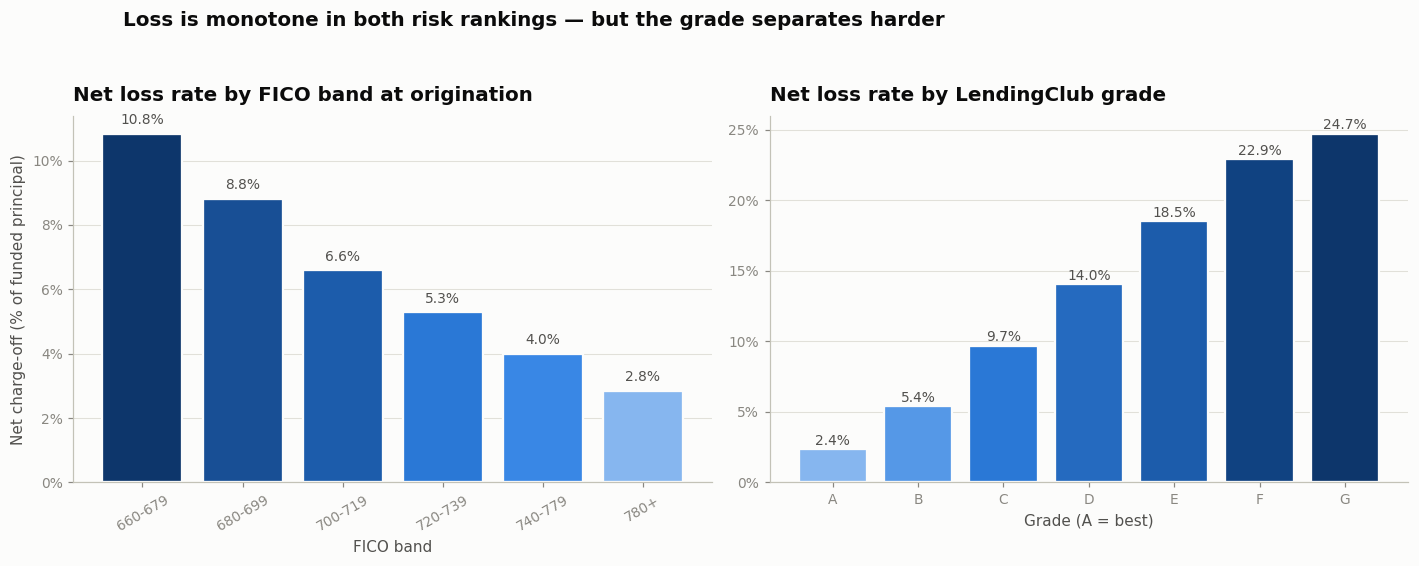

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# --- Panel 1: FICO band ------------------------------------------------------ #
ax = axes[0]
colors_fico = pl.ordinal_colors(len(by_fico))[::-1]  # dark = worst credit
bars = ax.bar(
    by_fico.index.astype(str), by_fico["Net loss rate"],
    color=colors_fico, edgecolor=pl.SURFACE, linewidth=1.5,
)
for b, v in zip(bars, by_fico["Net loss rate"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v*100:.1f}%",
            ha="center", fontsize=9, color=pl.INK_SECONDARY)
ax.set_title("Net loss rate by FICO band at origination", loc="left")
ax.set_xlabel("FICO band")
ax.set_ylabel("Net charge-off (% of funded principal)")
pl.pct_axis(ax, decimals=0)
pl.style_axes(ax)
ax.tick_params(axis="x", rotation=30)

# --- Panel 2: grade ---------------------------------------------------------- #
ax = axes[1]
colors_grade = pl.ordinal_colors(len(by_grade))
bars = ax.bar(
    by_grade.index.astype(str), by_grade["Net loss rate"],
    color=colors_grade, edgecolor=pl.SURFACE, linewidth=1.5,
)
for b, v in zip(bars, by_grade["Net loss rate"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v*100:.1f}%",
            ha="center", fontsize=9, color=pl.INK_SECONDARY)
ax.set_title("Net loss rate by LendingClub grade", loc="left")
ax.set_xlabel("Grade (A = best)")
ax.set_ylabel("")
pl.pct_axis(ax, decimals=0)
pl.style_axes(ax)

fig.suptitle(
    "Loss is monotone in both risk rankings — but the grade separates harder",
    x=0.09, ha="left", fontsize=13, fontweight="semibold", color=pl.INK_PRIMARY,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
pl.save_fig(fig, "03_loss_by_segment.png")
plt.show()

## Frequency vs severity: which term is doing the work?

Plot the two components side by side, on the same scale, and the asymmetry is
immediate.

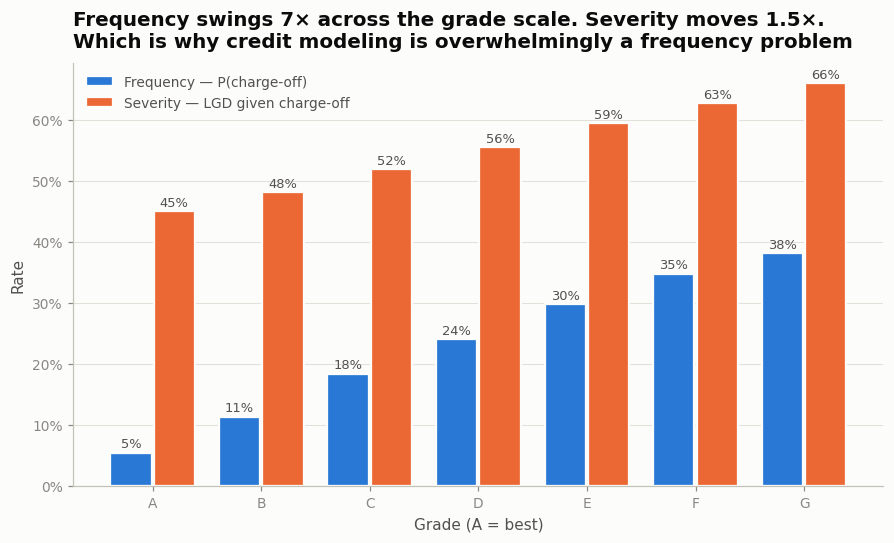

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5))

x = np.arange(len(by_grade))
width = 0.38
ax.bar(x - width / 2 - 0.01, by_grade["Frequency"], width,
       color=pl.CATEGORICAL[0], label="Frequency — P(charge-off)",
       edgecolor=pl.SURFACE, linewidth=1.5)
ax.bar(x + width / 2 + 0.01, by_grade["Severity (LGD)"], width,
       color=pl.CATEGORICAL[1], label="Severity — LGD given charge-off",
       edgecolor=pl.SURFACE, linewidth=1.5)

for xi, (f, s) in enumerate(zip(by_grade["Frequency"], by_grade["Severity (LGD)"])):
    ax.text(xi - width / 2 - 0.01, f + 0.008, f"{f*100:.0f}%", ha="center",
            fontsize=8.5, color=pl.INK_SECONDARY)
    ax.text(xi + width / 2 + 0.01, s + 0.008, f"{s*100:.0f}%", ha="center",
            fontsize=8.5, color=pl.INK_SECONDARY)

ax.set_xticks(x)
ax.set_xticklabels(by_grade.index.astype(str))
ax.set_xlabel("Grade (A = best)")
ax.set_ylabel("Rate")
ax.set_title(
    "Frequency swings 7× across the grade scale. Severity moves 1.5×.\n"
    "Which is why credit modeling is overwhelmingly a frequency problem",
    loc="left",
)
pl.pct_axis(ax, decimals=0)
pl.style_axes(ax)
ax.legend(loc="upper left")

pl.save_fig(fig, "03_frequency_vs_severity.png")
plt.show()

**Frequency runs from 5.5% in grade A to 38% in grade G — a factor of seven.
Severity moves from 45% to 66% — a factor of 1.5.** Both rise with risk, but
they are not remotely the same size of move.

Severity does carry real information, and it is worth understanding why it
rises: a worse borrower tends to fail *earlier* in the loan's life, so less
principal has amortised away by the time they stop paying. Severity is partly a
restatement of default timing.

But the multiplicative decomposition makes the priority obvious. Across the
grade scale, frequency contributes roughly a 7× swing and severity roughly
1.5×. If severity were the variable term, the modeling effort would go into
recovery and workout. It is not, so the effort goes into predicting *whether* a
loan defaults — which is exactly what notebook 04 does.

It is also a real difference from the catastrophe side of insurance, and worth
naming out loud in an interview. A property cat book is the mirror image:
frequency is low and lumpy, severity is enormously variable and is where the
whole tail lives. Consumer credit is high-frequency with tight severity. The
machinery transfers; the shape of the risk does not.

## The two-way view: FICO band × grade

The single-variable tables above each answer half the question. Crossing them
shows whether the grade is doing work *beyond* the FICO score — which is the
real test of an underwriting model.

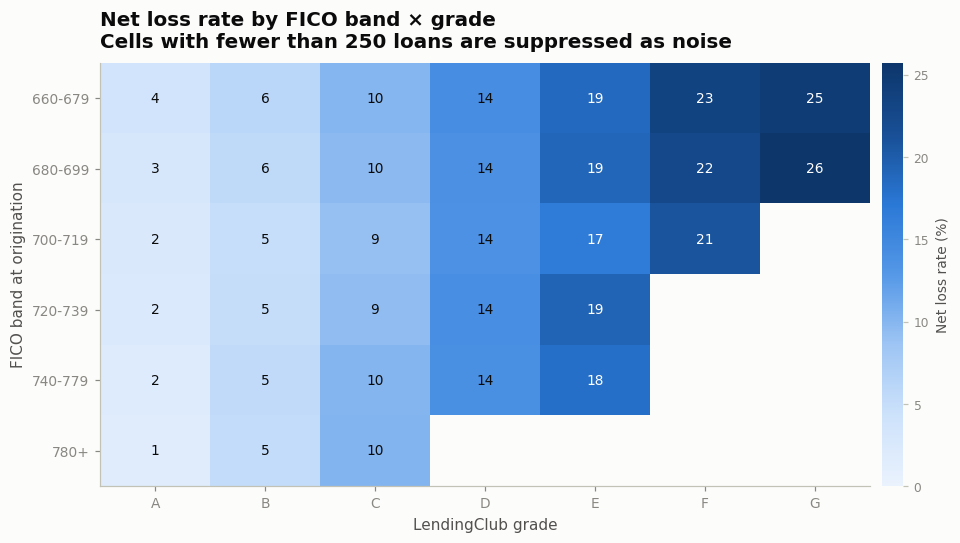

In [6]:
pivot_loss = df.pivot_table(
    index="fico_band", columns="grade",
    values="net_chargeoff", aggfunc="sum", observed=True,
) / df.pivot_table(
    index="fico_band", columns="grade",
    values="funded_amnt", aggfunc="sum", observed=True,
)

# Suppress thin cells: a loss rate computed on a handful of loans is just noise.
counts = df.pivot_table(
    index="fico_band", columns="grade", values="charged_off",
    aggfunc="size", observed=True,
)
pivot_loss = pivot_loss.where(counts >= 250)

fig, ax = plt.subplots(figsize=(9.5, 5))
data = (pivot_loss * 100).values.astype(float)
im = ax.imshow(data, cmap=pl.SEQ_BLUE, aspect="auto",
               vmin=0, vmax=np.nanmax(data))

ax.set_xticks(range(pivot_loss.shape[1]))
ax.set_xticklabels(pivot_loss.columns)
ax.set_yticks(range(pivot_loss.shape[0]))
ax.set_yticklabels(pivot_loss.index)
ax.set_xlabel("LendingClub grade")
ax.set_ylabel("FICO band at origination")
ax.set_title(
    "Net loss rate by FICO band × grade\n"
    "Cells with fewer than 250 loans are suppressed as noise",
    loc="left",
)
ax.grid(False)

threshold = np.nanmax(data) * 0.62
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color="#ffffff" if v > threshold else pl.INK_PRIMARY)

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.035)
cbar.set_label("Net loss rate (%)", color=pl.INK_SECONDARY, fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(color=pl.AXISLINE, labelcolor=pl.INK_MUTED, labelsize=8)

pl.save_fig(fig, "03_fico_grade_heatmap.png")
plt.show()

Read the heatmap **across a row**: hold FICO fixed and the loss rate still
climbs steeply with grade. A 700–719 borrower graded A loses a fraction of what
a 700–719 borrower graded E loses. The grade is not a repackaged FICO score —
it is carrying real, independent information (DTI, income verification, credit
utilisation, inquiries).

Now read **down a column**: hold grade fixed and FICO does much less. Within a
grade, the loss rate is nearly flat across FICO bands.

That asymmetry is the finding, and it has a direct consequence for notebook 04:
a model fit on borrower attributes *without* the grade is solving a genuinely
harder problem than one handed the grade, because the grade already contains a
multivariate view that no single bureau variable reproduces.

## Does the price cover the loss?

The point of segmenting is pricing. LendingClub charges more for worse grades —
the question is whether it charges *enough* more.

One unit conversion is needed to compare them. The interest rate is an annual
coupon; the loss numbers are cumulative over the life of the loan. A 36-month
level-pay loan has a weighted-average life of roughly 1.6 years (principal
amortises down from day one), so cumulative loss divided by ~1.6 puts loss on an
annual footing. It is an approximation and it is stated as one — but it is
accurate enough to answer a directional question.

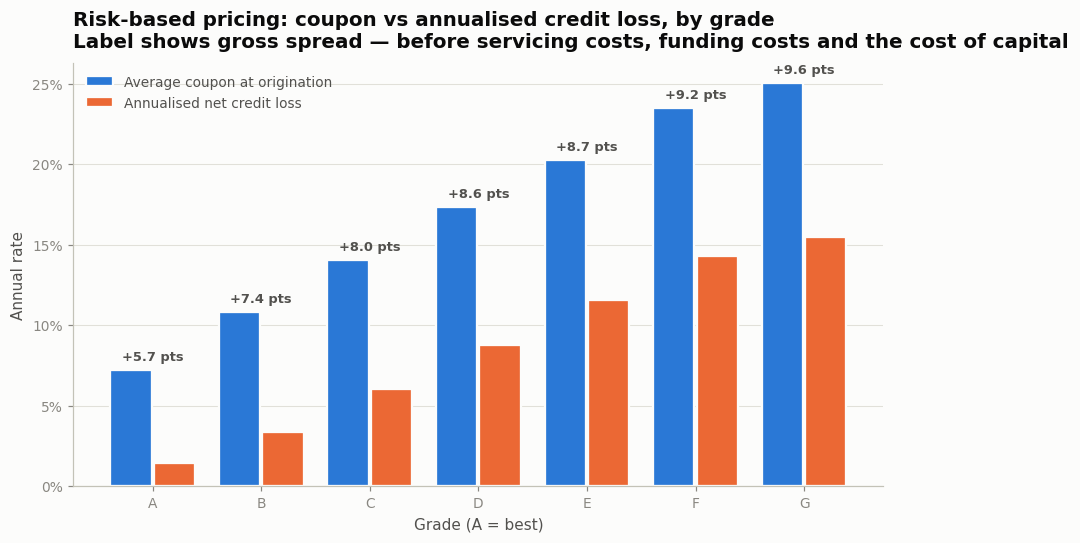

In [7]:
WAL_YEARS = 1.6  # weighted-average life of a 36-month level-pay amortising loan

pricing = by_grade[["Avg rate", "Net loss rate", "Funded ($M)"]].copy()
pricing["Annualised loss"] = pricing["Net loss rate"] / WAL_YEARS
pricing["Spread over loss"] = pricing["Avg rate"] - pricing["Annualised loss"]

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(pricing))
width = 0.38

ax.bar(x - width / 2 - 0.01, pricing["Avg rate"], width,
       color=pl.CATEGORICAL[0], label="Average coupon at origination",
       edgecolor=pl.SURFACE, linewidth=1.5)
ax.bar(x + width / 2 + 0.01, pricing["Annualised loss"], width,
       color=pl.CATEGORICAL[1], label="Annualised net credit loss",
       edgecolor=pl.SURFACE, linewidth=1.5)

for xi, (r, l) in enumerate(zip(pricing["Avg rate"], pricing["Annualised loss"])):
    ax.text(xi, max(r, l) + 0.006, f"+{(r-l)*100:.1f} pts",
            ha="center", fontsize=8.5, color=pl.INK_SECONDARY, fontweight="semibold")

ax.set_xticks(x)
ax.set_xticklabels(pricing.index.astype(str))
ax.set_xlabel("Grade (A = best)")
ax.set_ylabel("Annual rate")
ax.set_title(
    "Risk-based pricing: coupon vs annualised credit loss, by grade\n"
    "Label shows gross spread — before servicing costs, funding costs and the cost of capital",
    loc="left",
)
pl.pct_axis(ax, decimals=0)
pl.style_axes(ax)
ax.legend(loc="upper left")

pl.save_fig(fig, "03_pricing_adequacy.png")
plt.show()

In [8]:
pricing_fmt = pricing.copy()
for c in ["Avg rate", "Net loss rate", "Annualised loss", "Spread over loss"]:
    pricing_fmt[c] = (pricing_fmt[c] * 100).round(2).astype(str) + "%"
pricing_fmt["Funded ($M)"] = pricing_fmt["Funded ($M)"].round(0).astype(int)
pricing_fmt

,Avg rate,Net loss rate,Funded ($M),Annualised loss,Spread over loss
grade,,,,,
A,7.19%,2.35%,2189,1.47%,5.72%
B,10.83%,5.43%,3025,3.39%,7.43%
C,14.05%,9.69%,2487,6.06%,7.99%
D,17.34%,14.03%,1224,8.77%,8.57%
E,20.26%,18.49%,520,11.56%,8.7%
F,23.46%,22.9%,180,14.31%,9.15%
G,25.05%,24.72%,41,15.45%,9.6%


Gross spread stays positive across every grade, and it *widens* as credit gets
worse — the classic shape of a risk-based rate table that is doing its job.

Two honest caveats before anyone reads this as "the low grades are the best
trade":

1. **Gross is not net.** This spread pays for servicing, funding and the cost of
   equity held against the position. The apparent extra spread in grades E–G is
   thinner than it looks once those are charged against it.
2. **Spread is not risk-adjusted.** The low grades earn more spread *and* carry
   far more loss volatility — the same trade as writing a higher layer at a
   higher rate on line. Whether that is a good trade is a capital question, and
   notebook 05 is where the volatility gets quantified.

## Where did the 2016 deterioration come from?

Notebook 02 showed 2016 as the worst vintage on the board. Segmentation lets us
ask *which part of the book* did it — a broad drift, or a specific slice?

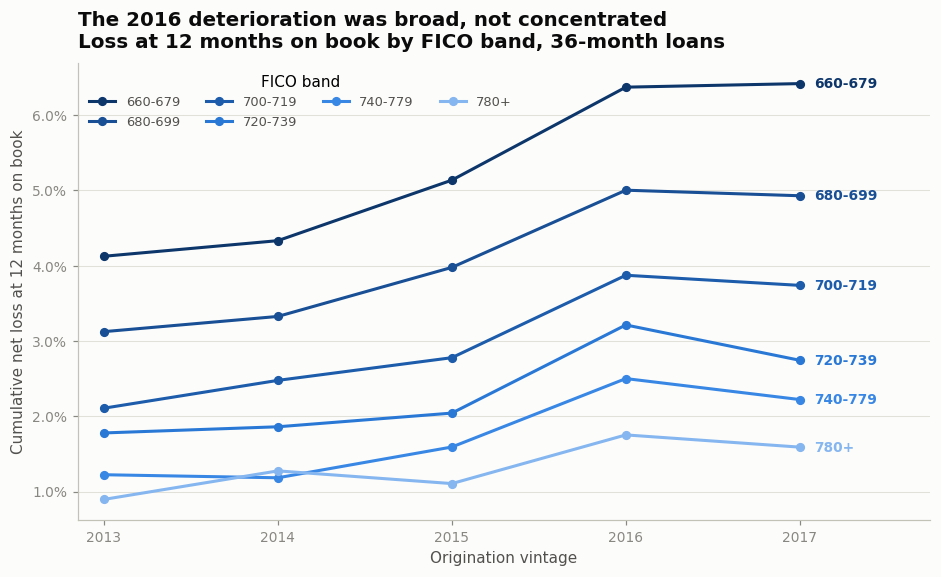

In [9]:
panel = pd.read_parquet(dp.VINTAGE_PANEL)
panel36 = panel[(panel["term_months"] == 36) & (panel["vintage_year"].between(2013, 2017))]

by_band = {}
for band in panel36["fico_band"].cat.categories:
    sub = panel36[panel36["fico_band"] == band]
    if len(sub) < 5000:
        continue
    tri = dp.vintage_triangle(sub, cohort_col="vintage_year", max_mob=12)
    by_band[band] = tri[12]

loss12 = pd.DataFrame(by_band)

fig, ax = plt.subplots(figsize=(10, 5.4))
colors = pl.ordinal_colors(loss12.shape[1])[::-1]

for (band, series), color in zip(loss12.items(), colors):
    s = series.dropna()
    ax.plot(s.index, s.values, color=color, marker="o", label=str(band))
    pl.annotate_last(ax, s.index[-1], s.values[-1], str(band), color, dx=0.08)

ax.set_xticks(loss12.index)
ax.set_xlabel("Origination vintage")
ax.set_ylabel("Cumulative net loss at 12 months on book")
ax.set_title(
    "The 2016 deterioration was broad, not concentrated\n"
    "Loss at 12 months on book by FICO band, 36-month loans",
    loc="left",
)
ax.set_xlim(loss12.index.min() - 0.15, loss12.index.max() + 0.75)
pl.pct_axis(ax)
pl.style_axes(ax)
ax.legend(title="FICO band", ncol=4, loc="upper left", fontsize=8.5)

pl.save_fig(fig, "03_deterioration_by_band.png")
plt.show()

In [10]:
loss12_tbl = (loss12 * 100).round(2)
loss12_tbl["vs 2013"] = (loss12_tbl.iloc[:, 0] / loss12_tbl.iloc[0, 0]).round(2)
loss12_tbl

,660-679,680-699,700-719,720-739,740-779,780+,vs 2013
vintage_year,,,,,,,
2013,4.12,3.12,2.11,1.78,1.22,0.90,1.00
2014,4.33,3.33,2.48,1.86,1.18,1.27,1.05
2015,5.14,3.98,2.78,2.04,1.59,1.11,1.25
2016,6.37,5.00,3.87,3.21,2.50,1.75,1.55
2017,6.42,4.93,3.74,2.74,2.22,1.59,1.56


**Every band deteriorated, and the good bands deteriorated proportionally more.**
From 2013 to 2016, loss at 12 months on book rose 55% in the 660–679 band — and
doubled in the 740–779 band (1.22% → 2.50%). The lines rise together rather than
fanning out from the bottom.

That rules out the easy explanation. If the damage were a **mix shift** — the
lender reaching further down the credit spectrum — you would see the bottom band
grow as a share of the book while each band's own loss rate held steady. Instead
the loss rate rose *inside* every band. The credit quality of a 740-FICO
LendingClub borrower in 2016 was genuinely worse than that of a 740-FICO
LendingClub borrower in 2013, at the same score.

## Decomposing 2016 → 2017: was the improvement real?

The aggregate 2017 vintage looked better (4.42% at 12 MOB vs 4.74% for 2016).
But look at the band-level rows and 2017 is barely different from 2016 — 6.42%
vs 6.37% in the bottom band, essentially flat.

So where did the aggregate improvement come from? Standard decomposition,
exactly as you would split a loss-ratio movement into rate, mix and frequency:

$$\Delta L \;=\; \underbrace{\sum_i (w^{17}_i - w^{16}_i)\,L^{16}_i}_{\text{mix effect}} \;+\; \underbrace{\sum_i w^{17}_i\,(L^{17}_i - L^{16}_i)}_{\text{within-band effect}}$$

In [11]:
weights = (
    panel36.pivot_table(
        index="vintage_year", columns="fico_band",
        values="funded_amnt", aggfunc="sum", observed=True,
    )
    .reindex(columns=loss12.columns)
)
weights = weights.div(weights.sum(axis=1), axis=0)

w16, w17 = weights.loc[2016], weights.loc[2017]
l16, l17 = loss12.loc[2016], loss12.loc[2017]

mix_effect = ((w17 - w16) * l16).sum()
within_effect = (w17 * (l17 - l16)).sum()

decomp = pd.DataFrame(
    {
        "2016 share of principal": (w16 * 100).round(1),
        "2017 share of principal": (w17 * 100).round(1),
        "Share change (pts)": ((w17 - w16) * 100).round(1),
        "2016 loss @12 MOB": (l16 * 100).round(2),
        "2017 loss @12 MOB": (l17 * 100).round(2),
    }
)
agg16 = (w16 * l16).sum()
agg17 = (w17 * l17).sum()

print(decomp.to_string())
print()
print(f"Aggregate loss @12 MOB, 2016 vintage:  {agg16:.2%}")
print(f"Aggregate loss @12 MOB, 2017 vintage:  {agg17:.2%}")
print(f"Change:                                {(agg17 - agg16) * 100:+.2f} pts")
print("-" * 56)
print(f"  MIX effect  (shift toward better bands):   {mix_effect * 100:+.2f} pts")
print(f"  WITHIN-BAND effect (tighter standards):    {within_effect * 100:+.2f} pts")
print(f"  Share of the improvement from mix:         {mix_effect / (agg17 - agg16):.0%}")

         2016 share of principal  2017 share of principal  Share change (pts)  2016 loss @12 MOB  2017 loss @12 MOB
660-679                     32.4                     28.8                -3.5               6.37               6.42
680-699                     26.6                     24.4                -2.3               5.00               4.93
700-719                     19.4                     19.4                -0.0               3.87               3.74
720-739                     10.4                     12.5                 2.0               3.21               2.74
740-779                      8.3                     10.8                 2.5               2.50               2.22
780+                         3.0                      4.3                 1.3               1.75               1.59

Aggregate loss @12 MOB, 2016 vintage:  4.74%
Aggregate loss @12 MOB, 2017 vintage:  4.42%
Change:                                -0.32 pts
------------------------------------------------

**About 60% of the 2017 improvement is mix, not underwriting.** LendingClub
shifted the book toward better credit — the 660–679 band fell from 32% to 29% of
funded principal while the 740+ bands grew from 11% to 15% — and that
reweighting delivers 0.19 of the 0.32-point improvement. The remaining 0.13
points is genuine within-band tightening, and even that is concentrated in the
upper bands: at the bottom of the score range, 2017 was marginally *worse* than
2016.

This distinction matters commercially. A mix shift is a **volume decision**: it
lowers loss by writing less of the risky business, and it can be reversed next
quarter by a growth target. Genuinely tighter underwriting is a **quality
decision** and tends to persist. Reading the aggregate number alone, you would
have called 2017 a credit turnaround. Reading it by band, it looks more like the
lender declining to compete for the bottom of its own book.

Same-band comparison is the tool that separates the two — and it is exactly the
question an actuary asks when a loss ratio moves: was that rate, exposure mix,
or underlying frequency?

---
**Next:** `04_default_model.ipynb` — a loan-level default probability model, led
by logistic regression, with a boosted benchmark to size what interpretability
costs.